# R04 - Money Expression Extraction with Mistral

This notebook runs a technical pilot on 1% of the rap corpus to extract money-related expressions from lyrics using a Mistral model served through vLLM.

## Objective
- Validate the extraction logic on a small sample before scaling up.
- Keep the output in a JSON list of [term, count] pairs.
- Target the model on GPU 2 only.

## Expected output format
- [["moula", 12], ["pèze", 7], ["bif", 4]]

## Notes
- Sample fraction: 1%
- Corpus filter: 10 to 4000 words
- Backend: OpenAI-compatible vLLM endpoint
- Model: Mistral-7B-Instruct-v0.3


In [2]:
import json
import os
import re
import subprocess
import time
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import requests
from tqdm.auto import tqdm

print("✓ Imports loaded")


✓ Imports loaded


In [35]:
# ============================================================================
# SECTION 1: CONFIGURATION
# --------------------------------------------------------------------
# Purpose: keep all model, corpus, GPU, and export settings in one place.
# Analysis: this design makes the pilot run easy to rerun and compare with
# future full-corpus executions without changing the extraction logic.
# ============================================================================

notebook_prefix = 'R04'
sample_label = '1pct_10to4000w'
pilot_fraction = 0.01
random_state = 42

model_name = 'mistralai/Mistral-7B-Instruct-v0.3'
gpu_index = 2
server_port = 8014

home = Path.home()
model_base = home / '.cache/huggingface/hub/models--mistralai--Mistral-7B-Instruct-v0.3/snapshots'
model_path = model_base
if model_base.exists():
    snapshots = sorted(model_base.glob('*'))
    if snapshots:
        model_path = snapshots[0]

vllm_python = home / 'miniconda3/envs/vllm_mistral/bin/python'
vllm_library_dir = home / 'miniconda3/envs/vllm_mistral/lib/python3.11/site-packages/vllm'

corpus_path = Path('corpus.csv')
export_dir = Path('export')
export_dir.mkdir(exist_ok=True)

server_log_path = export_dir / f'{notebook_prefix}_{sample_label}_vllm_server.log'
output_json_path = export_dir / f'{notebook_prefix}_{sample_label}_money_terms.json'
output_csv_path = export_dir / f'{notebook_prefix}_{sample_label}_money_terms.csv'

min_words_per_document = 10
max_words_per_document = 4000
max_retries = 2
request_timeout_seconds = 180

gpu_memory_utilization = 0.60
max_model_len = 8192
base_url = f'http://127.0.0.1:{server_port}'
models_url = f'{base_url}/v1/models'

print('=' * 80)
print('✓ Configuration loaded')
print(f'  Model: {model_name}')
print(f'  GPU: {gpu_index}')
print(f'  vLLM port: {server_port}')
print(f'  Pilot fraction: {pilot_fraction:.2%}')
print(f'  Corpus: {corpus_path}')
print(f'  Output JSON: {output_json_path}')
print('=' * 80)


✓ Configuration loaded
  Model: mistralai/Mistral-7B-Instruct-v0.3
  GPU: 2
  vLLM port: 8014
  Pilot fraction: 1.00%
  Corpus: corpus.csv
  Output JSON: export/R04_1pct_10to4000w_money_terms.json


In [36]:
# ============================================================================
# SECTION 2: vLLM SERVER STARTUP ON GPU 2
# --------------------------------------------------------------------
# Purpose: ensure the OpenAI-compatible vLLM endpoint is healthy before
# sending extraction requests. The model is explicitly bound to GPU 2.
# Analysis: this avoids hidden GPU drift and makes the pilot reproducible.
# ============================================================================

def endpoint_is_healthy():
    try:
        response = requests.get(models_url, timeout=5)
        return response.ok
    except requests.RequestException:
        return False

print('🔍 Checking vLLM endpoint health...')
if endpoint_is_healthy():
    print('✓ vLLM server already active')
else:
    print(f'🚀 Starting vLLM on GPU {gpu_index}...')
    server_command = [
        str(vllm_python), '-m', 'vllm.entrypoints.openai.api_server',
        '--model', str(model_path),
        '--served-model-name', model_name,
        '--host', '127.0.0.1',
        '--port', str(server_port),
        '--tensor-parallel-size', '1',
        '--dtype', 'bfloat16',
        '--gpu-memory-utilization', str(gpu_memory_utilization),
        '--max-model-len', str(max_model_len),
        '--no-enable-log-requests',
    ]
    server_environment = {
        **os.environ,
        'CUDA_VISIBLE_DEVICES': str(gpu_index),
        'LD_LIBRARY_PATH': f"{vllm_library_dir}:{os.environ.get('LD_LIBRARY_PATH', '')}",
    }
    with server_log_path.open('a', encoding='utf-8') as log:
        server_process = subprocess.Popen(
            server_command,
            stdout=log,
            stderr=subprocess.STDOUT,
            env=server_environment,
        )
    print('⏳ Waiting for server startup...')
    deadline = time.monotonic() + 900
    while time.monotonic() < deadline:
        if endpoint_is_healthy():
            print(f'✓ vLLM ready at {base_url}')
            break
        if server_process.poll() is not None:
            raise RuntimeError('vLLM crashed during startup')
        time.sleep(5)
    else:
        raise TimeoutError('vLLM did not start within 15 minutes')


🔍 Checking vLLM endpoint health...
✓ vLLM server already active


## Data preparation

This section loads the corpus and applies a deterministic 1% pilot sample after filtering on word count.
The goal is to keep the run representative while staying cheap and controllable.


In [37]:
# ============================================================================
# SECTION 3: CORPUS LOAD AND 1% PILOT SAMPLING
# --------------------------------------------------------------------
# Purpose: keep the pilot narrow and deterministic before a larger run.
# Analysis: filtering by word count reduces noise from empty or truncated
# lyrics and makes the sample more comparable across runs.
# ============================================================================

print('📖 Loading corpus...')
df = pd.read_csv(corpus_path, encoding='utf-8', on_bad_lines='skip')
print(f'  ✓ {len(df):,} documents loaded')

if 'doc_id' not in df.columns or 'lyrics' not in df.columns:
    raise KeyError(f"Required columns missing: {df.columns.tolist()}")

df = df.reset_index(drop=True)
df['word_count'] = df['lyrics'].fillna('').astype(str).str.split().str.len()
df = df[df['word_count'].between(min_words_per_document, max_words_per_document, inclusive='both')].copy()

sample_size = max(1, int(len(df) * pilot_fraction))
sample_df = df.sample(n=sample_size, random_state=random_state).copy()

print(f"\n🎯 Pilot sample selected: {len(sample_df):,} documents ({pilot_fraction:.2%})")
print(f"  - Word count range: {min_words_per_document}-{max_words_per_document}")
print(f"  - Example doc_id: {sample_df.iloc[0].get('doc_id', 'N/A')}")


📖 Loading corpus...
  ✓ 85,023 documents loaded

🎯 Pilot sample selected: 841 documents (1.00%)
  - Word count range: 10-4000
  - Example doc_id: 59867


## Prompt design and parsing

The extraction policy combines an extensive whitelist of positive examples with a controlled semantic extension.

### Money vocabulary policy

The whitelist is used as a set of good examples, not as a closed vocabulary. It includes standard, everyday, slang, regional, and currency expressions such as `argent`, `fric`, `blé`, `sous`, `thunes`, `pognon`, `cash`, `moula`, `pèze`, `flouze`, `dollar`, `dinar`, `euro`, `yuan`, `franc`, `peso`, and `roupie`.

The model may extract a relevant expression that is absent from the whitelist when its meaning clearly refers to money, cash, or currency. This makes the policy extensible while keeping the whitelist as a semantic guide. The model must not invent terms or select a word merely because it appears near a monetary expression.

### Excluded vocabulary

Institutional and financial-operation terms are excluded when they do not directly denote money. Examples include `banque`, `compte`, `salaire`, `solde`, `crédit`, `dette`, `investissement`, `paiement`, `transaction`, `budget`, and `finance`.

The parser normalizes accents, punctuation, casing, and spacing before applying these exclusions. It also enforces a strict JSON output contract while tolerating minor formatting drift from the model response.

### Analysis

This policy aims to capture ordinary and slang synonyms for money, together with currency names, without turning every financial or institutional reference into a money term. The 1% pilot is used to inspect the ranked frequencies before extending the extraction to a larger sample.

In [4]:
# ============================================================================
# SECTION 4: PROMPT DESIGN AND JSON PARSING
# --------------------------------------------------------------------
# Purpose: enforce a strict output contract and guide the model with positive
# money examples while allowing relevant expressions outside the list.
# Analysis: the parser normalizes variants and removes obvious finance-operation
# terms, but does not make the whitelist an exclusive vocabulary.
# ============================================================================

money_examples = [
    'argent', 'billet', 'fortune', 'fric', 'blé', 'sous', 'thunes', 'pognon', 'cash', 'moula',
    'pèze', 'flouze', 'tune', 'biff', 'bif', 'galette', 'gros sous',
    'dollar', 'dollars', 'euro', 'euros', 'dinar', 'dinars', 'yuan', 'fraiche'
    'franc', 'francs', 'liquide', 'livre', 'livres', 'peso', 'pesos', 'Pépettes','roupie', 'roupies',
    'maille', 'magot', 'Kopeck', 
    'money', 'moulah', 'moulaa', 'monnaie', 'flouz', 'patate', 'oseille', 'ronds', 'thune', 
    'grisb', 'grisbi', 'sous'
]

excluded_finance_terms = {
    'banque', 'banques', 'compte', 'comptes', 'salaire', 'salaires',
    'solde', 'soldes', 'crédit', 'credits', 'dette', 'dettes',
    'investissement', 'investissements', 'paiement', 'paiements',
    'transaction', 'transactions', 'budget', 'budgets', 'finance', 'finances'
}


def normalize_money_term(term):
    term = str(term).strip().lower()
    term = term.replace('’', "'").replace('“', '"').replace('”', '"')
    term = re.sub(r'[^a-zà-ÿ\s-]', '', term)
    return re.sub(r'\s+', ' ', term).strip()


def is_money_candidate(term):
    normalized = normalize_money_term(term)
    return len(normalized) > 2 and normalized not in excluded_finance_terms


def normalize_json_list(raw_text):
    cleaned = str(raw_text).strip()
    cleaned = re.sub(r'```(?:json)?', '', cleaned, flags=re.IGNORECASE)
    cleaned = cleaned.strip()
    cleaned = cleaned.replace('“', '"').replace('”', '"').replace('’', "'")

    try:
        parsed = json.loads(cleaned)
    except json.JSONDecodeError:
        match = re.search(r'\[.*\]', cleaned, flags=re.DOTALL)
        if not match:
            return []
        try:
            parsed = json.loads(match.group(0))
        except json.JSONDecodeError:
            return []

    if isinstance(parsed, dict):
        for key in ['items', 'results', 'terms']:
            if key in parsed and isinstance(parsed[key], list):
                parsed = parsed[key]
                break
        else:
            parsed = list(parsed.items())

    output = []
    for item in parsed:
        if isinstance(item, dict):
            term = item.get('term') or item.get('expression') or item.get('value')
            count = item.get('count') or item.get('frequency') or item.get('nb') or 0
            if term is not None:
                normalized_term = normalize_money_term(term)
                if is_money_candidate(normalized_term):
                    output.append({'term': normalized_term, 'count': int(count)})
        elif isinstance(item, (list, tuple)) and len(item) >= 2:
            term, count = item[0], item[1]
            normalized_term = normalize_money_term(term)
            if is_money_candidate(normalized_term):
                output.append({'term': normalized_term, 'count': int(count)})

    return output


def extract_money_terms(text):
    examples = ', '.join(money_examples)
    prompt = f"""You are an expert in French. Extract expressions directly related to money, cash, currency, or monetary slang.

Use this extensive whitelist as positive examples: {examples}
This list is not exhaustive. Also include a relevant standard, everyday, regional, or slang expression when its meaning clearly refers to money. Do not invent terms and do not include a word merely because it appears near a monetary expression.

Strict rules:
- Keep only terms genuinely linked to money or currency, whether standard or slang.
- Exclude institutional or financial-operation terms such as banque, compte, salaire, solde, crédit, investissement, paiement, transaction, or budget.
- Count repeated occurrences if the same term appears multiple times.
- Return valid JSON only, with no explanation.
- Exact format: [["term", count], ["other_term", count], ...]
- If nothing matches, return []

Text to analyze:
{text[:2000]}

JSON output only:"""

    payload = {
        'model': model_name,
        'prompt': prompt,
        'temperature': 0,
        'max_tokens': 256,
    }

    for _ in range(1, max_retries + 2):
        try:
            response = requests.post(f'{base_url}/v1/completions', json=payload, timeout=request_timeout_seconds)
            response.raise_for_status()
            choice_text = response.json().get('choices', [{}])[0].get('text', '').strip()
            if not choice_text:
                continue
            parsed = normalize_json_list(choice_text)
            if parsed:
                return parsed
        except Exception:
            pass
    return []

print('✓ Prompt and parser ready')

✓ Prompt and parser ready


In [39]:
# ============================================================================
# SECTION 5: EXTRACTION ON THE 1% PILOT SAMPLE
# --------------------------------------------------------------------
# Purpose: run the extraction pass with visible progress.
# Analysis: a progress bar makes it easier to spot malformed JSON or
# model drift early, before any full-corpus pass.
# ============================================================================

all_counts = Counter()
all_rows = []

with tqdm(total=len(sample_df), desc='Money extraction', unit='lyrics', dynamic_ncols=True) as progress:
    for idx, row in sample_df.iterrows():
        text = str(row.get('lyrics', '')).strip()
        if not text:
            progress.update(1)
            continue

        extracted = extract_money_terms(text)
        for item in extracted:
            term = str(item.get('term', '')).strip().lower()
            count = int(item.get('count', 0) or 0)
            if term and count > 0:
                all_counts[term] += count
                all_rows.append({
                    'doc_id': row.get('doc_id', idx),
                    'term': term,
                    'count': count,
                })
        progress.update(1)

final_terms = sorted(all_counts.items(), key=lambda x: (-x[1], x[0]))
final_pairs = [[term, count] for term, count in final_terms]

print(f"\n✓ Distinct terms detected: {len(final_terms)}")
for term, count in final_terms[:20]:
    print(f'  - {term}: {count}')

with output_json_path.open('w', encoding='utf-8') as output_file:
    json.dump(final_pairs, output_file, ensure_ascii=False, indent=2)

pd.DataFrame(all_rows).to_csv(output_csv_path, index=False, encoding='utf-8')

print(f"\n✓ JSON export: {output_json_path}")
print(f'✓ CSV export: {output_csv_path}')


Money extraction:   0%|          | 0/841 [00:00<?, ?lyrics/s]


✓ Distinct terms detected: 3231
  - argent: 548
  - dollar: 371
  - moula: 353
  - euro: 300
  - thunes: 259
  - fric: 258
  - money: 248
  - moulah: 218
  - pognon: 201
  - gros sous: 199
  - sous: 190
  - cash: 175
  - biff: 140
  - oseille: 107
  - patate: 97
  - blé: 91
  - flouze: 88
  - grisb: 83
  - bif: 82
  - thune: 80

✓ JSON export: export/R04_1pct_10to4000w_money_terms.json
✓ CSV export: export/R04_1pct_10to4000w_money_terms.csv


## Result visualization

The chart below ranks the top 30 money expressions by frequency in the 1% pilot sample. It helps identify the dominant slang terms before deciding whether to expand to the full corpus.


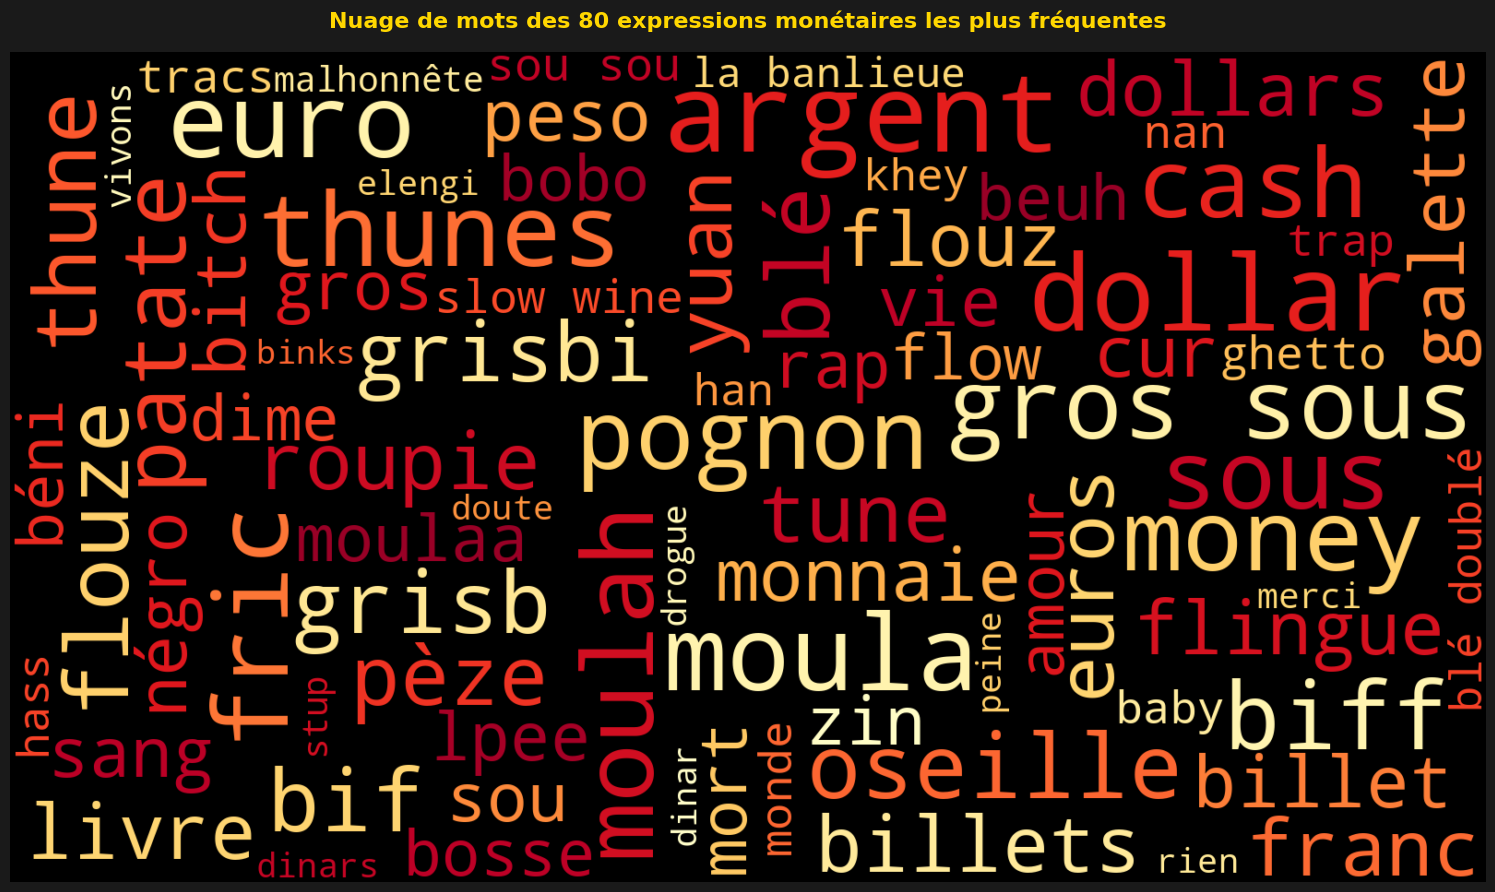

✓ Nuage de mots enregistré : export/R04_1pct_10to4000w_top80_money_terms_wordcloud.png


In [21]:
# ============================================================================
# SECTION 6: WORD-CLOUD VISUALIZATION
# --------------------------------------------------------------------
# Purpose: display the 80 most frequent money expressions as a word cloud.
# Analysis: word size represents frequency, while the local Rap hip-hop skill
# provides a consistent dark, gold, orange, and red visual identity.
# ============================================================================

from pathlib import Path

import numpy as np
from wordcloud import WordCloud

if 'final_pairs' not in locals() and 'final_terms' in locals():
    final_pairs = [[term, count] for term, count in final_terms]

if 'final_pairs' in locals() and final_pairs:
    top_80_df = pd.DataFrame(final_pairs, columns=['term', 'count']).head(80)
    frequencies = dict(zip(top_80_df['term'].astype(str), top_80_df['count'].astype(int)))
    log_frequencies = {term: np.log1p(count) for term, count in frequencies.items()}

    wordcloud = WordCloud(
        width=1600,
        height=900,
        background_color='#000000',
        colormap='YlOrRd',
        max_words=80,
        relative_scaling=0.7,
        min_font_size=10,
        max_font_size=120,
        prefer_horizontal=0.7,
        collocations=False,
        random_state=42,
        margin=8,
    ).generate_from_frequencies(log_frequencies)

    wordcloud_chart_path = Path('export') / 'R04_1pct_10to4000w_top80_money_terms_wordcloud.png'
    plt.figure(figsize=(16, 9), facecolor='#1a1a1a')
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(
        'Nuage de mots des 80 expressions monétaires les plus fréquentes',
        color='#FFD700',
        fontsize=16,
        fontweight='bold',
        pad=18,
    )
    plt.tight_layout(pad=1)
    plt.savefig(wordcloud_chart_path, dpi=300, bbox_inches='tight', facecolor='#1a1a1a')
    plt.show()
    print(f'✓ Nuage de mots enregistré : {wordcloud_chart_path}')
else:
    print("Aucune expression disponible ; exécutez d'abord la section d'extraction.")

## Cooccurrence analysis and UMAP projection

The analysis now examines the 50 most frequent money terms together. For each term, a binary document-term matrix records whether it appears in each lyric, and the term-by-term cooccurrence matrix counts shared lyrics.

Each term is then represented by its cooccurrence profile and projected into two dimensions with UMAP. Nearby points indicate similar cooccurrence patterns, not necessarily similar spelling or meaning. This 2D representation is exploratory and will serve as the input for a later clustering step.

The cooccurrence matrix and UMAP coordinates are exported so the projection can be inspected or reused without rerunning extraction.

/home/cbenavent/test/.venv/lib64/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


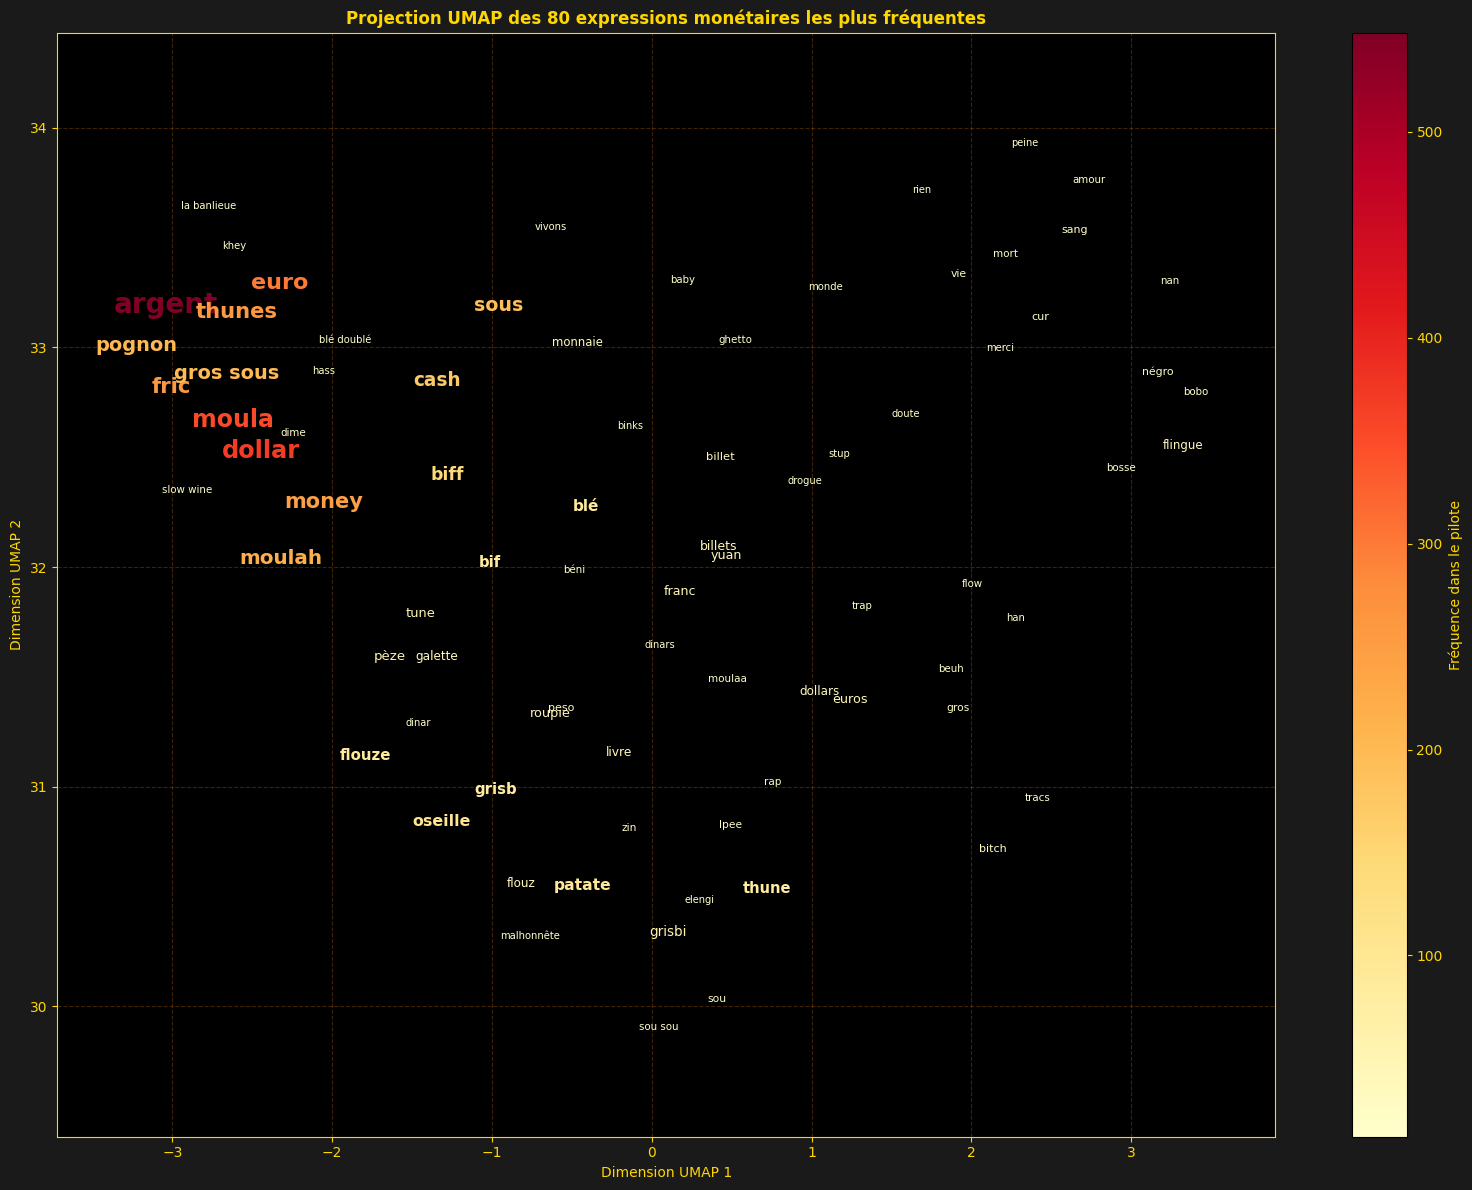

✓ Terms projected: 80
✓ Cooccurrence matrix: export/R04_1pct_10to4000w_top80_cooccurrence.csv
✓ UMAP coordinates: export/R04_1pct_10to4000w_top80_umap_2d.csv
✓ UMAP labels-only chart: export/R04_1pct_10to4000w_top80_umap_2d_labels_only.png


In [23]:
# ============================================================================
# SECTION 7: TOP-80 COOCCURRENCE AND UMAP PROJECTION
# ============================================================================

from collections import Counter
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap.umap_ as umap


def run_top80_umap_analysis():
    global all_rows, all_counts, final_terms

    if 'all_rows' not in globals() or 'final_terms' not in globals():
        saved_csv = Path('export') / 'R04_1pct_10to4000w_money_terms.csv'
        if not saved_csv.exists():
            print('No extraction results available. Run the 1% extraction section first.')
            return None
        loaded_rows = pd.read_csv(saved_csv, encoding='utf-8')
        required_columns = {'doc_id', 'term', 'count'}
        if not required_columns.issubset(loaded_rows.columns):
            print(f'Saved extraction is missing columns: {required_columns}')
            return None
        all_rows = loaded_rows.to_dict('records')
        all_counts = Counter()
        for saved_row in all_rows:
            all_counts[str(saved_row['term'])] += int(saved_row['count'])
        final_terms = sorted(all_counts.items(), key=lambda item: (-item[1], item[0]))
        print(f'Loaded saved extraction: {saved_csv}')

    analysis_df = pd.DataFrame(all_rows)
    if analysis_df.empty:
        print('The extraction returned no terms; UMAP analysis was skipped.')
        return None

    analysis_df['term'] = analysis_df['term'].map(normalize_money_term)
    analysis_df['doc_id'] = analysis_df['doc_id'].astype(str)
    document_term = pd.crosstab(analysis_df['doc_id'], analysis_df['term']).astype('int8')
    top_80_terms = [term for term, _ in final_terms[:80] if term in document_term.columns]
    if len(top_80_terms) < 3:
        print('Fewer than three extracted terms are available; UMAP analysis was skipped.')
        return None

    document_term = document_term.reindex(columns=top_80_terms, fill_value=0)
    cooccurrence_matrix = document_term.T.dot(document_term).astype('int32')
    cooccurrence_matrix.index.name = 'term'
    cooccurrence_matrix.columns.name = 'term'
    cooccurrence_path = Path('export') / 'R04_1pct_10to4000w_top80_cooccurrence.csv'
    cooccurrence_matrix.to_csv(cooccurrence_path, encoding='utf-8')

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=min(15, len(top_80_terms) - 1),
        min_dist=0.25,
        metric='cosine',
        random_state=42,
    )
    embedding = reducer.fit_transform(cooccurrence_matrix.to_numpy(dtype=float))
    umap_df = pd.DataFrame({
        'term': top_80_terms,
        'x': embedding[:, 0],
        'y': embedding[:, 1],
        'frequency': [all_counts[term] for term in top_80_terms],
    })
    umap_path = Path('export') / 'R04_1pct_10to4000w_top80_umap_2d.csv'
    umap_df.to_csv(umap_path, index=False, encoding='utf-8')

    frequency_scale = np.sqrt(umap_df['frequency'].clip(lower=1))
    label_sizes = np.interp(frequency_scale, (frequency_scale.min(), frequency_scale.max()), (7, 20))
    frequency_norm = mpl.colors.Normalize(
        vmin=umap_df['frequency'].min(),
        vmax=umap_df['frequency'].max(),
    )
    frequency_cmap = mpl.colormaps['YlOrRd']

    chart_path = Path('export') / 'R04_1pct_10to4000w_top80_umap_2d_labels_only.png'
    fig, ax = plt.subplots(figsize=(16, 12), facecolor='#1a1a1a')
    ax.set_facecolor('#000000')
    for (_, term_row), label_size in zip(umap_df.iterrows(), label_sizes):
        ax.text(
            term_row['x'],
            term_row['y'],
            term_row['term'],
            ha='center',
            va='center',
            fontsize=float(label_size),
            color=frequency_cmap(frequency_norm(term_row['frequency'])),
            fontweight='bold' if term_row['frequency'] >= umap_df['frequency'].quantile(0.75) else 'normal',
        )

    x_margin = max((umap_df['x'].max() - umap_df['x'].min()) * 0.06, 0.5)
    y_margin = max((umap_df['y'].max() - umap_df['y'].min()) * 0.06, 0.5)
    ax.set_xlim(umap_df['x'].min() - x_margin, umap_df['x'].max() + x_margin)
    ax.set_ylim(umap_df['y'].min() - y_margin, umap_df['y'].max() + y_margin)

    scalar_mappable = mpl.cm.ScalarMappable(norm=frequency_norm, cmap=frequency_cmap)
    scalar_mappable.set_array(umap_df['frequency'].to_numpy())
    colorbar = fig.colorbar(scalar_mappable, ax=ax)
    colorbar.set_label('Fréquence dans le pilote', color='#FFD700')
    colorbar.ax.tick_params(colors='#FFD700')
    ax.set_title('Projection UMAP des 80 expressions monétaires les plus fréquentes', color='#FFD700', fontweight='bold')
    ax.set_xlabel('Dimension UMAP 1', color='#FFD700')
    ax.set_ylabel('Dimension UMAP 2', color='#FFD700')
    ax.tick_params(colors='#FFD700')
    for spine in ax.spines.values():
        spine.set_color('#FFD700')
    ax.grid(alpha=0.25, color='#FF8C00', linestyle='--')
    fig.tight_layout()
    fig.savefig(chart_path, dpi=300, bbox_inches='tight', facecolor='#1a1a1a')
    plt.show()

    print(f'✓ Terms projected: {len(top_80_terms)}')
    print(f'✓ Cooccurrence matrix: {cooccurrence_path}')
    print(f'✓ UMAP coordinates: {umap_path}')
    print(f'✓ UMAP labels-only chart: {chart_path}')
    return umap_df


umap_df = run_top80_umap_analysis()

## Temporal lexical density analysis

This section measures the annual lexical density of the extracted money terms over the project-standard 1990-2024 interval. For each year, density is defined as the number of occurrences of a money term divided by the total number of words in the corpus for that year.

The stacked area chart displays the densities of the 15 most frequent money terms. The denominator is the annual sum of `word_count` across the corpus, not the number of extracted money terms. This makes the metric comparable across years with different corpus sizes.

The figure follows the local Rap hip-hop palette: black and dark gray backgrounds with gold, orange, and crimson accents.

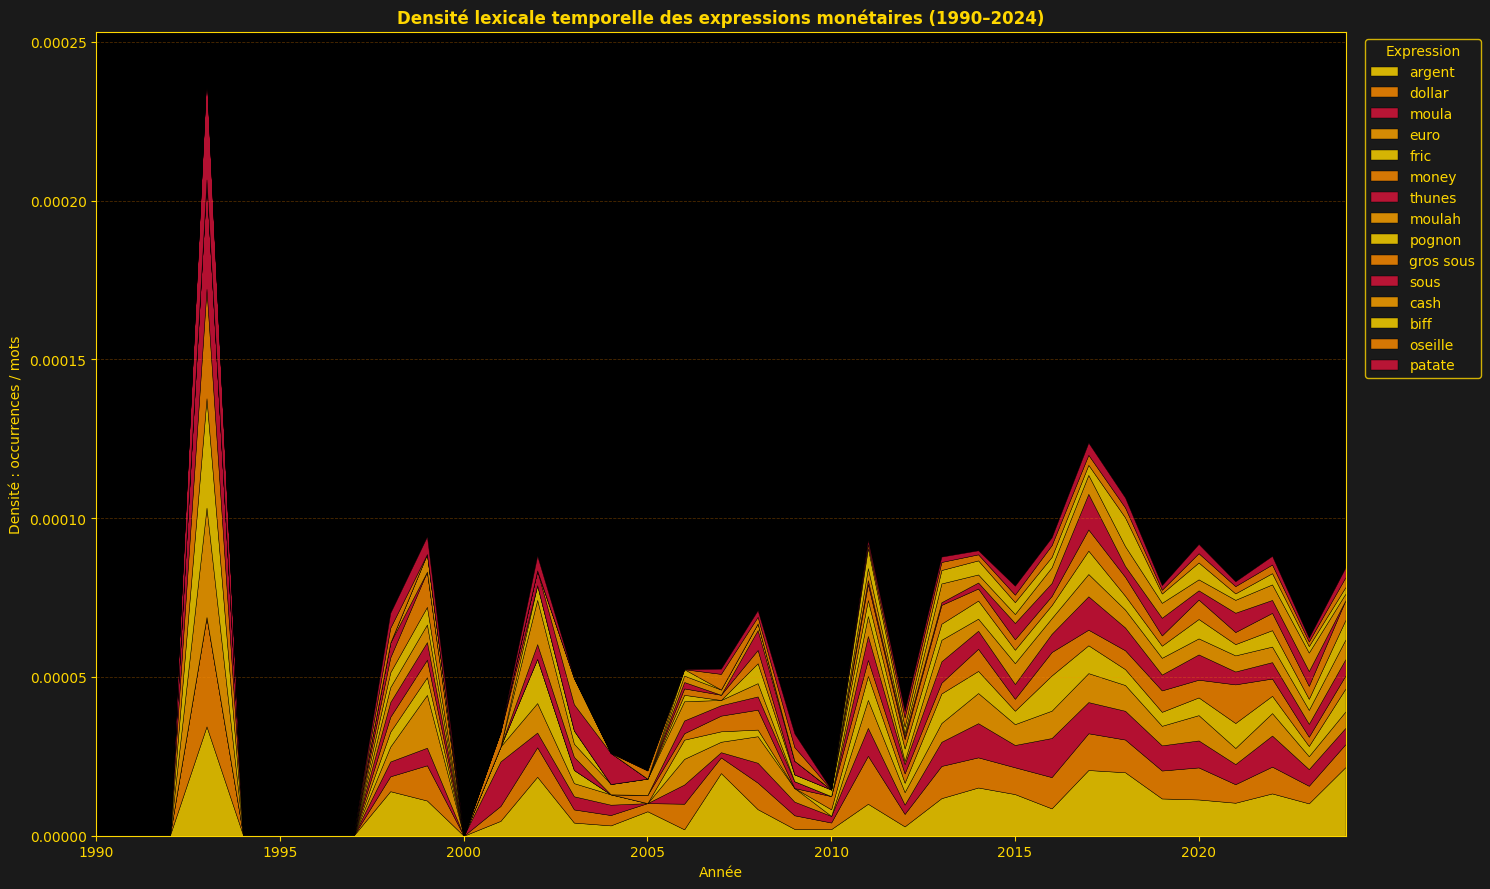

✓ Temporal column: year
✓ Project interval: 1990-2024
✓ Density formula: term frequency / total corpus words per year
✓ Density data: export/R04_1pct_10to4000w_top15_money_terms_density.csv
✓ Density stacked area chart: export/R04_1pct_10to4000w_top15_money_terms_density_stacked_area.png


In [18]:
# ============================================================================
# SECTION 8: TEMPORAL LEXICAL DENSITY AS A STACKED AREA CHART
# --------------------------------------------------------------------
# Purpose: show the annual density of the most frequent money terms.
# Analysis: density equals the term frequency divided by the total number of
# words in the corpus during the same year.
# ============================================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


PROJECT_MIN_YEAR = 1990
PROJECT_MAX_YEAR = 2024


def run_temporal_density_analysis():
    if 'all_rows' not in globals() or not all_rows:
        saved_csv = Path('export') / 'R04_1pct_10to4000w_money_terms.csv'
        if not saved_csv.exists():
            print('No extraction results available for temporal density analysis.')
            return None
        extraction_df = pd.read_csv(saved_csv, encoding='utf-8')
    else:
        extraction_df = pd.DataFrame(all_rows)

    if extraction_df.empty:
        print('The extraction is empty; temporal density analysis was skipped.')
        return None

    if 'df' not in globals() or 'doc_id' not in df.columns:
        if not Path('corpus.csv').exists():
            print('The corpus file is unavailable; temporal density analysis was skipped.')
            return None
        corpus_df = pd.read_csv('corpus.csv', encoding='utf-8', on_bad_lines='skip')
    else:
        corpus_df = df.copy()

    if 'year' not in corpus_df.columns:
        print(f"The project temporal column 'year' is missing. Available columns: {corpus_df.columns.tolist()}")
        return None

    if 'word_count' not in corpus_df.columns:
        if 'n_words' in corpus_df.columns:
            corpus_df['word_count'] = pd.to_numeric(corpus_df['n_words'], errors='coerce')
        elif 'lyrics' in corpus_df.columns:
            corpus_df['word_count'] = corpus_df['lyrics'].fillna('').astype(str).str.split().str.len()
        else:
            print('No word-count column or lyrics field is available for lexical density.')
            return None

    metadata = corpus_df[['doc_id', 'year', 'word_count']].copy()
    metadata['doc_id'] = metadata['doc_id'].astype(str)
    metadata['period'] = pd.to_numeric(metadata['year'], errors='coerce')
    metadata['word_count'] = pd.to_numeric(metadata['word_count'], errors='coerce').fillna(0)
    metadata = metadata[
        metadata['period'].between(PROJECT_MIN_YEAR, PROJECT_MAX_YEAR, inclusive='both')
    ].dropna(subset=['period']).copy()
    metadata['period'] = metadata['period'].astype(int)

    # The denominator is the total number of corpus words in each year.
    annual_total_words = metadata.groupby('period')['word_count'].sum()
    annual_total_words = annual_total_words.replace(0, np.nan)

    extraction_df['doc_id'] = extraction_df['doc_id'].astype(str)
    extraction_df['term'] = extraction_df['term'].astype(str).str.strip().str.lower()
    merged = extraction_df.merge(metadata[['doc_id', 'period']], on='doc_id', how='inner')
    if merged.empty:
        print('No extracted terms could be matched to a year in the project interval.')
        return None

    annual_term_counts = merged.groupby(['period', 'term'], as_index=False)['count'].sum()
    top_terms = [term for term, _ in sorted(
        merged.groupby('term')['count'].sum().items(),
        key=lambda item: (-item[1], item[0]),
    )[:15]]

    density_counts = (
        annual_term_counts[annual_term_counts['term'].isin(top_terms)]
        .pivot(index='period', columns='term', values='count')
        .fillna(0)
        .reindex(columns=top_terms, fill_value=0)
        .div(annual_total_words, axis=0)
        .fillna(0)
        .sort_index()
    )

    if density_counts.empty:
        print('No temporal lexical densities could be computed.')
        return None

    density_path = Path('export') / 'R04_1pct_10to4000w_top15_money_terms_density.csv'
    density_counts.to_csv(density_path, encoding='utf-8')

    # The Rap project hip-hop palette: gold, orange, and crimson on dark gray.
    hip_hop_palette = ['#FFD700', '#FF8C00', '#DC143C', '#FFA500']
    colors = [hip_hop_palette[index % len(hip_hop_palette)] for index in range(len(top_terms))]

    density_chart_path = Path('export') / 'R04_1pct_10to4000w_top15_money_terms_density_stacked_area.png'
    periods = density_counts.index.to_numpy()
    fig, ax = plt.subplots(figsize=(15, 9), facecolor='#1a1a1a')
    ax.set_facecolor('#000000')
    ax.stackplot(
        periods,
        density_counts.T.to_numpy(),
        labels=density_counts.columns,
        colors=colors,
        alpha=0.82,
        edgecolor='#000000',
        linewidth=0.35,
    )
    ax.set_title('Densité lexicale temporelle des expressions monétaires (1990–2024)', color='#FFD700', fontweight='bold')
    ax.set_xlabel('Année', color='#FFD700')
    ax.set_ylabel('Densité : occurrences / mots', color='#FFD700')
    ax.set_xlim(PROJECT_MIN_YEAR, PROJECT_MAX_YEAR)
    ax.tick_params(colors='#FFD700')
    for spine in ax.spines.values():
        spine.set_color('#FFD700')
    ax.grid(axis='y', color='#FF8C00', linewidth=0.6, alpha=0.3, linestyle='--')
    legend = ax.legend(title='Expression', loc='upper left', bbox_to_anchor=(1.01, 1), frameon=True)
    legend.get_frame().set_facecolor('#1a1a1a')
    legend.get_frame().set_edgecolor('#FFD700')
    for text in legend.get_texts():
        text.set_color('#FFD700')
    legend.get_title().set_color('#FFD700')
    fig.tight_layout()
    fig.savefig(density_chart_path, dpi=300, bbox_inches='tight', facecolor='#1a1a1a')
    plt.show()

    print('✓ Temporal column: year')
    print(f'✓ Project interval: {PROJECT_MIN_YEAR}-{PROJECT_MAX_YEAR}')
    print('✓ Density formula: term frequency / total corpus words per year')
    print(f'✓ Density data: {density_path}')
    print(f'✓ Density stacked area chart: {density_chart_path}')
    return density_counts


temporal_density_counts = run_temporal_density_analysis()

In [41]:
# ============================================================================
# SECTION 7: SUMMARY
# --------------------------------------------------------------------
# Purpose: provide a quick readout of the pilot result and export files.
# Analysis: this is the gate before deciding whether to expand to a full run.
# ============================================================================

print('=' * 80)
print('SUMMARY')
print('=' * 80)
print(f'Pilot fraction: {pilot_fraction:.2%}')
print(f'Distinct terms: {len(final_pairs):,}')
print(f'Total occurrences: {sum(count for _, count in final_pairs):,}')
print(f'JSON file: {output_json_path}')
print(f'CSV file: {output_csv_path}')
print('')
print(json.dumps(final_pairs[:10], ensure_ascii=False, indent=2))


SUMMARY
Pilot fraction: 1.00%
Distinct terms: 3,231
Total occurrences: 11,144
JSON file: export/R04_1pct_10to4000w_money_terms.json
CSV file: export/R04_1pct_10to4000w_money_terms.csv

[
  [
    "argent",
    548
  ],
  [
    "dollar",
    371
  ],
  [
    "moula",
    353
  ],
  [
    "euro",
    300
  ],
  [
    "thunes",
    259
  ],
  [
    "fric",
    258
  ],
  [
    "money",
    248
  ],
  [
    "moulah",
    218
  ],
  [
    "pognon",
    201
  ],
  [
    "gros sous",
    199
  ]
]
